**Module** : CCS4340 - Machine Learning     
**Acitivity** : Week 06 Lab Acitivity   
**Submitted by** : CIT-23-02-0162 | Jayani Sashikala  
**Date of Submission** : 2026/01/06

**Introduction**

# 1️⃣ **DATA EXPLORATION**

##  **Import Required Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


##  **Load Iris Dataset**

In [3]:
df = pd.read_csv("iris.csv")

In [4]:
df

,sepalLength,sepalWidth,petalLength,petalWidth,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


##  Basic Dataset Inspection

In [5]:
df.shape

(150, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sepalLength  150 non-null    float64
 1   sepalWidth   150 non-null    float64
 2   petalLength  150 non-null    float64
 3   petalWidth   150 non-null    float64
 4   species      150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
df.describe()

,sepalLength,sepalWidth,petalLength,petalWidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


# 2️⃣ **DATA PREPROCESSING**

## Seperate Features and Target

In [9]:
x = df[['sepalLength', 'sepalWidth', 'petalLength', 'petalWidth']]

In [10]:
y = df['species']

## Split the Dataset

## Feature Scaling

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()

In [13]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 3️⃣ **MODELING**

## Train KNN Model (k=5)

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)

KNeighborsClassifier()

## Make Predictions

In [15]:
y_pred = knn.predict(x_test_scaled)

In [16]:
y_pred

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa'], dtype=object)

#  4️⃣ **MODEL EVALUATION**

## ⚪ Accuracy

In [17]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


## ⚪ Confution Matrix

In [18]:
matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", matrix)

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## ⚪ Classification Report

In [19]:
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Different values of k

In [20]:
# Define k values
k_values = [1,2,3,4,5,6,7,8,9,10]
accuracy_list = []

# Train and evaluate for each k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    y_pred = knn.predict(x_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)
    print(f"k = {k}, Accuracy = {acc}")




k = 1, Accuracy = 1.0
k = 2, Accuracy = 1.0
k = 3, Accuracy = 1.0
k = 4, Accuracy = 1.0
k = 5, Accuracy = 1.0
k = 6, Accuracy = 1.0
k = 7, Accuracy = 1.0
k = 8, Accuracy = 1.0
k = 9, Accuracy = 1.0
k = 10, Accuracy = 1.0


# 5️⃣ Visualization

## Confusion Matrix Visualization

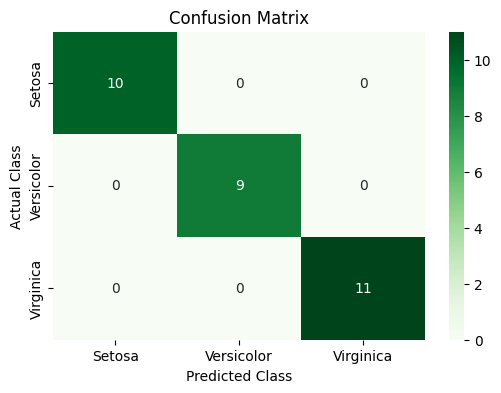

In [22]:
class_names = ['Setosa', 'Versicolor', 'Virginica']

plt.figure(figsize=(6, 4))
sns.heatmap(
    cmatrix,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()


## Accuracy vs k Visualization

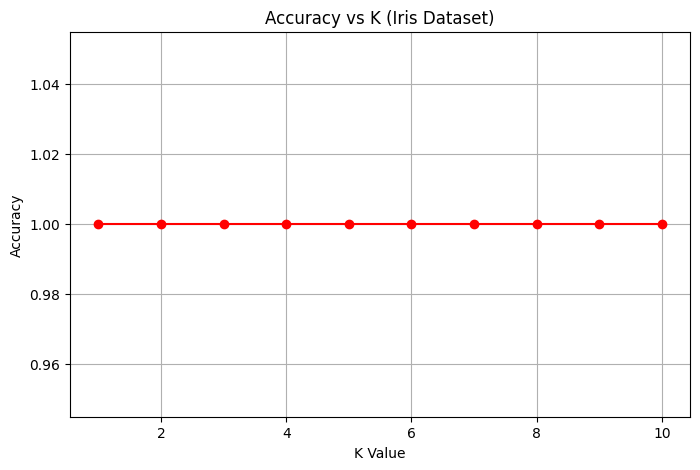

In [23]:
# Plot
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_list, marker='o', color='red')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K (Iris Dataset)")
plt.grid(True)
plt.show()

## Predict for a New flower

In [24]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]
# Sepal length = 5.1
# Sepal width = 3.5
# Petal length = 1.4
# Petal width = 0.2

In [25]:
new_flower_scaled = scaler.transform(new_flower)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [26]:
prediction = knn.predict(new_flower_scaled)
prediction

array(['setosa'], dtype=object)